In [119]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

eps = 1e-9

train_raw = pd.read_csv("Updated_Training.csv")
test_raw  = pd.read_csv("Updated_Test.csv")
train_raw.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,Conf.Record,Non-ConferenceRecord,RoadWL,NETSOS,NETNonConfSOS,Quadrant1,Quadrant2,Quadrant3,Quadrant4,ORtg,DRtg,AdjT,Luck,PTS,FG%,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF
0,2020-21-UCDavis,2020-21,UC Davis,Big West,NaN,NaN,223.0,224.0,240.0,211.0,8-Sep,5-Jul,3-Feb,3-Apr,264.0,287.0,0-0,0-3,2-Jan,3-Aug,98.0,102.3,69.2,0.087,72.5,44.7,33.2,77.9,9.2,22.2,31.5,10.9,7.4,2.8,14.6,19.6
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43.0,AL,70.0,70.0,20.0,75.0,15-12,12-Sep,Jun-00,8-Mar,9.0,238.0,10-May,2-Apr,Feb-00,Apr-00,107.1,94.2,68.3,0.090,69.4,42.6,32.1,72.7,10.9,26.6,37.4,15.9,4.5,4.7,13.0,19.8
2,2020-21-ULM,2020-21,ULM,Sun Belt,NaN,NaN,292.0,292.0,244.0,214.0,19-Jul,14-May,5-Feb,10-Feb,313.0,263.0,0-0,0-1,7-Feb,11-May,93.2,105.4,67.1,-0.040,64.2,41.6,34.0,70.3,7.9,22.5,30.4,13.7,7.4,2.8,13.0,16.7
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,NaN,NaN,301.0,301.0,200.0,195.0,16-May,13-May,0-3,9-Feb,242.0,54.0,0-1,0-2,6-Feb,7-Mar,92.5,112.0,70.3,0.003,68.5,42.4,32.4,70.2,8.7,23.0,31.6,12.9,6.9,2.6,14.2,17.1
4,2020-21-Colgate,2020-21,Colgate,Patriot,57.0,AQ,9.0,9.0,154.0,169.0,14-1,14-1,0-0,Jun-00,257.0,NaN,0-0,Feb-00,1-Jun,Jun-00,110.3,101.0,72.2,0.048,85.2,49.3,40.3,72.3,9.8,30.1,39.9,17.6,7.1,3.4,10.8,16.2


In [120]:
#Clean the dataset
MONTH_MAP   = {"Jan":"1","Feb":"2","Mar":"3","Apr":"4","May":"5","Jun":"6",
               "Jul":"7","Aug":"8","Sep":"9","Oct":"10","Nov":"11","Dec":"12"}
RECORD_COLS = ["WL","Conf.Record","Non-ConferenceRecord","RoadWL",
               "Quadrant1","Quadrant2","Quadrant3","Quadrant4"]

def parse_records(df):
    df = df.copy()
    for col in RECORD_COLS:
        if col not in df.columns: continue
        s = df[col].astype(str)
        for m, n in MONTH_MAP.items():
            s = s.str.replace(m, n, regex=False)
        sp = s.str.split("-", expand=True)
        if sp.shape[1] >= 2:
            df[f"{col}_W"] = pd.to_numeric(sp[0], errors="coerce")
            df[f"{col}_L"] = pd.to_numeric(sp[1], errors="coerce")
        df.drop(columns=[col], inplace=True)
    return df

train = parse_records(train_raw)
test  = parse_records(test_raw)

train.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,NETSOS,NETNonConfSOS,ORtg,DRtg,AdjT,Luck,PTS,FG%,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF,WL_W,WL_L,Conf.Record_W,Conf.Record_L,Non-ConferenceRecord_W,Non-ConferenceRecord_L,RoadWL_W,RoadWL_L,Quadrant1_W,Quadrant1_L,Quadrant2_W,Quadrant2_L,Quadrant3_W,Quadrant3_L,Quadrant4_W,Quadrant4_L
0,2020-21-UCDavis,2020-21,UC Davis,Big West,NaN,NaN,223.0,224.0,240.0,211.0,264.0,287.0,98.0,102.3,69.2,0.087,72.5,44.7,33.2,77.9,9.2,22.2,31.5,10.9,7.4,2.8,14.6,19.6,8,9,5,7,3,2,3,4,0,0,0,3,2,1,3,8
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43.0,AL,70.0,70.0,20.0,75.0,9.0,238.0,107.1,94.2,68.3,0.090,69.4,42.6,32.1,72.7,10.9,26.6,37.4,15.9,4.5,4.7,13.0,19.8,15,12,12,9,6,0,8,3,10,5,2,4,2,0,4,0
2,2020-21-ULM,2020-21,ULM,Sun Belt,NaN,NaN,292.0,292.0,244.0,214.0,313.0,263.0,93.2,105.4,67.1,-0.040,64.2,41.6,34.0,70.3,7.9,22.5,30.4,13.7,7.4,2.8,13.0,16.7,19,7,14,5,5,2,10,2,0,0,0,1,7,2,11,5
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,NaN,NaN,301.0,301.0,200.0,195.0,242.0,54.0,92.5,112.0,70.3,0.003,68.5,42.4,32.4,70.2,8.7,23.0,31.6,12.9,6.9,2.6,14.2,17.1,16,5,13,5,0,3,9,2,0,1,0,2,6,2,7,3
4,2020-21-Colgate,2020-21,Colgate,Patriot,57.0,AQ,9.0,9.0,154.0,169.0,257.0,NaN,110.3,101.0,72.2,0.048,85.2,49.3,40.3,72.3,9.8,30.1,39.9,17.6,7.1,3.4,10.8,16.2,14,1,14,1,0,0,6,0,0,0,2,0,1,6,6,0


In [121]:
print(f"Loaded  train {train.shape}  test {test.shape}")
print(f"Train: {train['Overall Seed'].notna().sum()} tournament  "
      f"/ {train['Overall Seed'].isna().sum()} non-tournament")
print(f"Test:  {test_raw['Bid Type'].notna().sum()} tournament  "
      f"/ {test_raw['Bid Type'].isna().sum()} non-tournament")

Loaded  train (1353, 44)  test (451, 43)
Train: 249 tournament  / 1104 non-tournament
Test:  91 tournament  / 360 non-tournament


In [122]:
print(train.isna().sum())

RecordID                     0
Season                       0
Team                         0
Conference                   0
Overall Seed              1104
Bid Type                  1104
NET Rank                     5
PrevNET                      5
AvgOppNETRank                5
AvgOppNET                    5
NETSOS                       5
NETNonConfSOS               15
ORtg                         0
DRtg                         0
AdjT                         0
Luck                         0
PTS                          5
FG%                          5
3P%                          5
FT%                          5
OR                           5
DR                           5
REB                          5
AST                          5
STL                          5
BLK                          5
TO                           5
PF                           5
WL_W                         0
WL_L                         0
Conf.Record_W                0
Conf.Record_L                0
Non-Conf

In [123]:
#Feature Engineer
POWER_CONFS = {"ACC", "Big 12", "Big East", "Big Ten", "Pac-12", "SEC"}

def engineer(df):
    df = df.copy()

    # win rates
    df["WinPct"]     = df["WL_W"]         / (df["WL_W"]         + df["WL_L"]         + eps)
    df["ConfWinPct"] = df["Conf.Record_W"] / (df["Conf.Record_W"]+ df["Conf.Record_L"]+ eps)
    df["RoadWinPct"] = df["RoadWL_W"]      / (df["RoadWL_W"]     + df["RoadWL_L"]     + eps)
    df["Q1_WinRate"] = df["Quadrant1_W"]   / (df["Quadrant1_W"]  + df["Quadrant1_L"]  + eps)
    df["Q2_WinRate"] = df["Quadrant2_W"]   / (df["Quadrant2_W"]  + df["Quadrant2_L"]  + eps)

    # resume quality
    df["Q1_Net"]           = df["Quadrant1_W"] - df["Quadrant1_L"]
    df["Q2_Net"]           = df["Quadrant2_W"] - df["Quadrant2_L"]
    df["Bad_Losses"]       = df["Quadrant3_L"] + df["Quadrant4_L"]
    df["Good_Wins"]        = df["Quadrant1_W"] * 2 + df["Quadrant2_W"]
    df["High_Level_Games"] = (df["Quadrant1_W"] + df["Quadrant1_L"] +
                              df["Quadrant2_W"]  + df["Quadrant2_L"])
    df["ResumeScore"]      = (df["Quadrant1_W"]*3 + df["Quadrant2_W"]*2
                              - df["Quadrant3_L"]*2 - df["Quadrant4_L"]*3)

    # efficiency
    df["EffMargin"]   = df["ORtg"] - df["DRtg"]
    df["NET_Delta"]   = df["PrevNET"] - df["NET Rank"]   # positive = improving
    df["NetMomentum"] = df["NET_Delta"] / (df["NET Rank"] + 1)
    df["SOS_Diff"]    = df["NETSOS"] - df["NETNonConfSOS"]
    df["log_NET"]     = np.log1p(df["NET Rank"])

    # kenpom gap: teams with high efficiency but poor NET are often under-seeded
    df["KenPom_Gap"]  = df["EffMargin"] - (50 - df["NET Rank"]) * 0.3

    # committee flags
    df["Bid_AQ"]       = (df["Bid Type"] == "AQ").astype(int)
    df["In_Tournament"]= df["Bid Type"].notna().astype(int)
    df["OnTheBubble"]  = ((df["NET Rank"] >= 30) & (df["NET Rank"] <= 70)).astype(int)
    df["TopTen"]       = (df["NET Rank"] <= 10).astype(int)
    df["IsPowerConf"]  = df["Conference"].isin(POWER_CONFS).astype(int)

    # mid-major ceiling: same NET rank but non-power conf = worse seed
    df["MidMajor_Ceiling"] = df["NET Rank"] * (1 - df["IsPowerConf"])

    # interactions
    df["NET_x_Eff"]    = df["NET Rank"]    * df["EffMargin"]
    df["NET_x_Win"]    = df["NET Rank"]    * df["WinPct"]
    df["AQ_x_NET"]     = df["Bid_AQ"]      * df["NET Rank"]
    df["Q1Rate_x_NET"] = df["Q1_WinRate"]  * df["NET Rank"]

    # where team sits among ALL teams in its season
    season_n       = df.groupby("Season")["NET Rank"].transform("count")
    df["NET_SRank"] = df.groupby("Season")["NET Rank"].rank(ascending=True)
    df["Eff_SRank"] = df.groupby("Season")["EffMargin"].rank(ascending=False)
    df["NET_Pct"]   = df["NET_SRank"] / season_n
    df["NET_Pct"]   = df["NET_Pct"].fillna(1.0)   # teams with no NET rank → worst

    return df

train = engineer(train)
test  = engineer(test)


In [124]:
# 3. Test Conference each season to see how model perform (Preping)

seeded_ref  = train.dropna(subset=["Overall Seed"])
global_mean = seeded_ref["Overall Seed"].mean()
seasons     = sorted(seeded_ref["Season"].unique())

conf_loo = {
    s: seeded_ref[seeded_ref["Season"] != s]
         .groupby("Conference")["Overall Seed"].mean().to_dict()
    for s in seasons
}

train["Conf_AvgSeed"] = [
    conf_loo.get(r.Season, {}).get(r.Conference, global_mean)
    for r in train.itertuples()
]
test["Conf_AvgSeed"] = (
    test["Conference"]
    .map(seeded_ref.groupby("Conference")["Overall Seed"].mean())
    .fillna(global_mean)
)

# conference power rank: avg NET of top-4 teams per season
conf_power = (
    seeded_ref.groupby(["Conference","Season"])
    .apply(lambda x: x.nsmallest(4, "NET Rank")["NET Rank"].mean())
    .reset_index(name="Conf_Power_Rank")
)
train = train.merge(conf_power, on=["Conference","Season"], how="left")
test  = test.merge(conf_power,  on=["Conference","Season"], how="left")

train["target"] = train["Overall Seed"].fillna(0)

In [125]:
#4 Feature Selection
ALL_FEATURES = [
    "NET Rank","PrevNET","NET_Delta","NetMomentum","log_NET",
    "NETSOS","NETNonConfSOS","SOS_Diff","AvgOppNETRank","AvgOppNET",
    "ORtg","DRtg","EffMargin","AdjT","Luck","KenPom_Gap",
    "WinPct","ConfWinPct","RoadWinPct","Q1_WinRate","Q2_WinRate",
    "WL_W","WL_L","Conf.Record_W","Conf.Record_L","RoadWL_W","RoadWL_L",
    "Quadrant1_W","Quadrant1_L","Quadrant2_W","Quadrant2_L",
    "Quadrant3_L","Quadrant4_L",
    "Q1_Net","Q2_Net","Bad_Losses","Good_Wins","High_Level_Games","ResumeScore",
    "PTS","FG%","3P%","FT%","OR","DR","REB","AST","STL","BLK","TO","PF",
    "Bid_AQ","In_Tournament","OnTheBubble","TopTen","IsPowerConf",
    "MidMajor_Ceiling","NET_x_Eff","NET_x_Win","AQ_x_NET","Q1Rate_x_NET",
    "NET_SRank","Eff_SRank","NET_Pct",
    "Conf_AvgSeed","Conf_Power_Rank",
]

# keep only columns that exist in both train and test
ALL_FEATURES = [f for f in ALL_FEATURES if f in train.columns and f in test.columns]
train_clean = train.dropna(subset=["NET Rank"]).copy()


In [126]:
# split quadrant vs other features
quad_cols  = [c for c in ALL_FEATURES if "Quadrant" in c or c in
              ["Q1_Net","Q2_Net","Bad_Losses","Good_Wins",
               "High_Level_Games","ResumeScore","Q1_WinRate","Q2_WinRate"]]
other_cols = [c for c in ALL_FEATURES if c not in quad_cols]


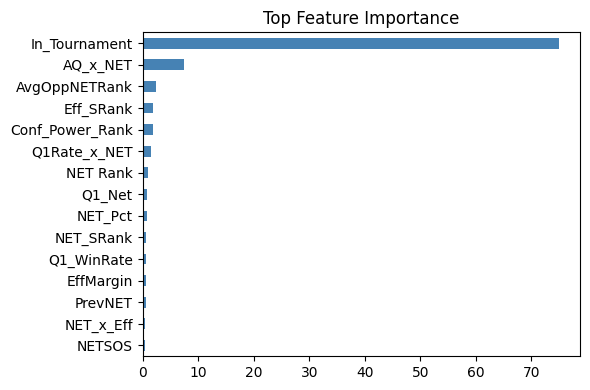

Selected features: ['NETSOS', 'NET_x_Eff', 'PrevNET', 'EffMargin', 'Q1_WinRate', 'NET_SRank', 'NET_Pct', 'Q1_Net', 'NET Rank', 'Q1Rate_x_NET', 'Conf_Power_Rank', 'Eff_SRank', 'AvgOppNETRank', 'AQ_x_NET', 'In_Tournament']


In [127]:

# prepare training matrix
X_all = train_clean[ALL_FEATURES]
y_all = train_clean["target"]

# store medians for later use (e.g., test set)
train_meds = X_all[other_cols].median()

# fast feature screening model
model = CatBoostRegressor(iterations=300, depth=4, random_seed=42, verbose=0)
model.fit(X_all, y_all)

# select top features
importance = pd.Series(model.feature_importances_, index=ALL_FEATURES).sort_values()
FEATURES   = importance.tail(15).index.tolist()

# plot
plt.figure(figsize=(6,4))
importance.tail(15).plot.barh(color="steelblue")
plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()

print("Selected features:", FEATURES)

In [128]:
# rebuild X with only selected features
X      = train_clean[FEATURES]
X_test = test[FEATURES]
y      = y_all

is_tourney = y.values > 0
n_t        = int(test_raw["Bid Type"].notna().sum())
n_all      = len(test)

print(f"Features: {len(FEATURES)} | Train: {len(X)} rows | Test: {len(X_test)} rows")
assert len(X_test) == 451, f"Expected 451 test rows, got {len(X_test)}"

Features: 15 | Train: 1348 rows | Test: 451 rows


In [129]:
# 5. CROSS VALIDATION  —  3-model blend
#    CatBoost + ExtraTrees + HistGBR
#    Each tested separately; blend weights chosen from OOF RMSE
CB_PARAMS  = dict(iterations=1000, learning_rate=0.03, depth=6,
                  l2_leaf_reg=3, random_seed=42, verbose=0)
ET_PARAMS  = dict(n_estimators=1000, min_samples_leaf=2,
                  random_state=42, n_jobs=-1)
HGB_PARAMS = dict(max_iter=1000, learning_rate=0.03, max_depth=6,
                  min_samples_leaf=5, random_state=42)

KF5 = KFold(n_splits=5, shuffle=True, random_state=42)

oof_cb  = np.zeros(len(X))
oof_et  = np.zeros(len(X))
oof_hgb = np.zeros(len(X))

fold_cb  = []; fold_et  = []; fold_hgb = []
train_rmses, val_rmses = [], []

print(f"\n{'Fold':<5} {'CatBoost':>7} {'ExtraTrees':>7} {'HistGBR':>7} {'Blend':>8} {'Gap':>7}")
print("─" * 45)

for fold, (tr, vl) in enumerate(KF5.split(X), 1):
    cb  = CatBoostRegressor(**CB_PARAMS)
    et  = ExtraTreesRegressor(**ET_PARAMS)
    hgb = HistGradientBoostingRegressor(**HGB_PARAMS)

    cb.fit(X.iloc[tr],  y.iloc[tr],
           eval_set=(X.iloc[vl], y.iloc[vl]),
           early_stopping_rounds=50)
    et.fit(X.iloc[tr],  y.iloc[tr])
    hgb.fit(X.iloc[tr], y.iloc[tr])

    oof_cb[vl]  = cb.predict(X.iloc[vl])
    oof_et[vl]  = et.predict(X.iloc[vl])
    oof_hgb[vl] = hgb.predict(X.iloc[vl])

    fold_cb.append(cb); fold_et.append(et); fold_hgb.append(hgb)

    blend_vl = 0.40*oof_cb[vl] + 0.40*oof_et[vl] + 0.20*oof_hgb[vl]
    r_tr = np.sqrt(mean_squared_error(y.iloc[tr], et.predict(X.iloc[tr])))
    r_vl = np.sqrt(mean_squared_error(y.iloc[vl], blend_vl))

    train_rmses.append(r_tr)
    val_rmses.append(r_vl)

    r_cb  = np.sqrt(mean_squared_error(y.iloc[vl], oof_cb[vl]))
    r_et  = np.sqrt(mean_squared_error(y.iloc[vl], oof_et[vl]))
    r_hgb = np.sqrt(mean_squared_error(y.iloc[vl], oof_hgb[vl]))

    print(f"  {fold}    {r_cb:>6.3f}  {r_et:>6.3f}  {r_hgb:>6.3f}  {r_vl:>7.3f}  {r_vl-r_tr:>+6.3f}")



Fold  CatBoost ExtraTrees HistGBR    Blend     Gap
─────────────────────────────────────────────
  1     2.354   2.406   2.303    2.312  +1.645
  2     1.990   2.054   2.230    2.006  +1.274
  3     1.932   1.930   2.111    1.870  +1.141
  4     3.104   3.223   3.673    3.211  +2.582
  5     2.275   2.434   2.599    2.315  +1.608


In [ ]:
#Find the best ratio for the blending technique
est_rmse, best_w = np.inf, None

for w_cb in np.arange(0,1.01,0.05):
    for w_et in np.arange(0,1.01-w_cb,0.05):
        w_hgb = 1 - w_cb - w_et
        blend = w_cb*oof_cb + w_et*oof_et + w_hgb*oof_hgb
        r = np.sqrt(mean_squared_error(y[is_tourney], blend[is_tourney]))
        if r < best_rmse:
            best_rmse, best_w = r, (w_cb, w_et, w_hgb)

print(f"Best RMSE: {best_rmse:.3f}")
print(f"Best blend ratio → CB:{best_w[0]:.2f}  ET:{best_w[1]:.2f}  HGB:{best_w[2]:.2f}")

Best RMSE: 5.473
Best blend ratio → CB:0.75  ET:0.25  HGB:0.00


In [131]:
# ──────────────────────────────────────────────────────────────────────────────
# 6. LEAVE-ONE-SEASON-OUT  (temporal honesty check)
# ──────────────────────────────────────────────────────────────────────────────
seeded_df = train_clean[train_clean["Overall Seed"].notna()].copy()
X_s = seeded_df[FEATURES]
y_s = seeded_df["Overall Seed"]

loso_preds = np.zeros(len(seeded_df))
for tr, vl in GroupKFold(n_splits=5).split(X_s, y_s, groups=seeded_df["Season"]):
    m = CatBoostRegressor(**CB_PARAMS)
    m.fit(X_s.iloc[tr], y_s.iloc[tr])
    loso_preds[vl] = m.predict(X_s.iloc[vl])

loso_by_season = {
    s: np.sqrt(mean_squared_error(
        y_s.values[seeded_df["Season"].values == s],
        loso_preds[seeded_df["Season"].values == s]
    ))
    for s in sorted(seeded_df["Season"].unique())
}
loso_mean = np.mean(list(loso_by_season.values()))

print("Leave-One-Season-Out:")
for s, r in loso_by_season.items():
    print(f"  {s}:  {r:.3f}")
print(f"  Average:  {loso_mean:.3f}")


Leave-One-Season-Out:
  2020-21:  6.205
  2021-22:  5.546
  2022-23:  5.753
  2023-24:  4.939
  2024-25:  4.734
  Average:  5.435


In [ ]:
# 7. FINAL MODELS  (train on all data)

final_cb  = CatBoostRegressor(**CB_PARAMS)
final_et  = ExtraTreesRegressor(**ET_PARAMS)
final_hgb = HistGradientBoostingRegressor(**HGB_PARAMS)

final_cb.fit(X, y)
final_et.fit(X, y)
final_hgb.fit(X, y)


# compute final out-of-fold (oof) blend using best weights
w_cb, w_et, w_hgb = best_w
oof_blend = w_cb*oof_cb + w_et*oof_et + w_hgb*oof_hgb
oof_rmse_t = np.sqrt(mean_squared_error(y[is_tourney], oof_blend[is_tourney]))
kaggle_est = oof_rmse_t
avg_gap = np.mean(np.array(val_rmses) - np.array(train_rmses))


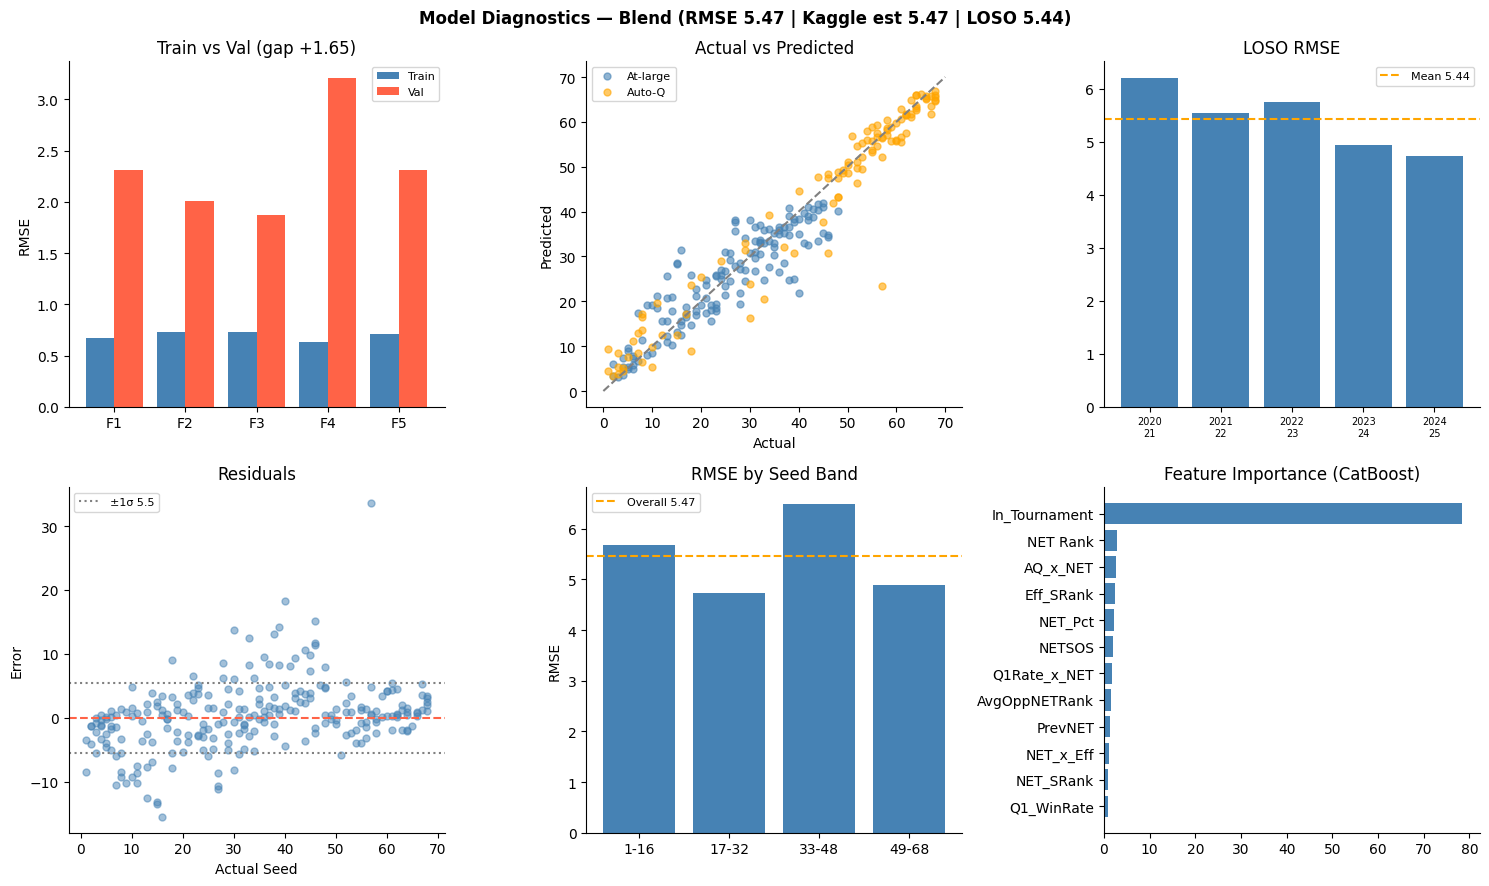

In [135]:
# 8. DIAGNOSTICS PLOT
actual_t  = y.values[is_tourney]
pred_t    = oof_blend[is_tourney]
residuals = actual_t - pred_t
is_aq     = (train_clean["Bid Type"] == "AQ").values[is_tourney]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    f"Model Diagnostics — Blend "
    f"(RMSE {oof_rmse_t:.2f} | Kaggle est {kaggle_est:.2f} | LOSO {loso_mean:.2f})",
    fontsize=12, fontweight="bold"
)

# 1 — Train vs Validation
ax = axes[0,0]
x = np.arange(len(train_rmses))
ax.bar(x-0.2, train_rmses, 0.4, label="Train", color="steelblue")
ax.bar(x+0.2, val_rmses,   0.4, label="Val",   color="tomato")
ax.set_xticks(x)
ax.set_xticklabels([f"F{i+1}" for i in x])
ax.set_title(f"Train vs Val (gap {avg_gap:+.2f})")
ax.set_ylabel("RMSE")
ax.legend(fontsize=8)

# 2 — Actual vs Predicted
ax = axes[0,1]
ax.scatter(actual_t[~is_aq], pred_t[~is_aq], s=25, alpha=.6,
           label="At-large", color="steelblue")
ax.scatter(actual_t[is_aq], pred_t[is_aq], s=25, alpha=.6,
           label="Auto-Q", color="orange")
ax.plot([0,70],[0,70],"--",color="gray")
ax.set(xlabel="Actual", ylabel="Predicted", title="Actual vs Predicted")
ax.legend(fontsize=8)

# 3 — LOSO by Season
ax = axes[0,2]
vals = list(loso_by_season.values())
ax.bar(range(len(vals)), vals, color="steelblue")
ax.axhline(loso_mean, ls="--", color="orange", label=f"Mean {loso_mean:.2f}")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([s.replace("-", "\n") for s in loso_by_season], fontsize=7)
ax.set_title("LOSO RMSE")
ax.legend(fontsize=8)

# 4 — Residuals
ax = axes[1,0]
ax.scatter(actual_t, residuals, s=25, alpha=.5, color="steelblue")
ax.axhline(0, color="tomato", ls="--")
sigma = residuals.std()
ax.axhline(sigma,  color="gray", ls=":", label=f"±1σ {sigma:.1f}")
ax.axhline(-sigma, color="gray", ls=":")
ax.set(xlabel="Actual Seed", ylabel="Error", title="Residuals")
ax.legend(fontsize=8)

# 5 — RMSE by Seed Band
ax = axes[1,1]
bands = [(1,16),(17,32),(33,48),(49,68)]
rmse = [np.sqrt(mean_squared_error(actual_t[(actual_t>=l)&(actual_t<=h)],
                                   pred_t[(actual_t>=l)&(actual_t<=h)]))
        for l,h in bands]
labels = [f"{l}-{h}" for l,h in bands]

ax.bar(labels, rmse, color="steelblue")
ax.axhline(oof_rmse_t, ls="--", color="orange", label=f"Overall {oof_rmse_t:.2f}")
ax.set_title("RMSE by Seed Band")
ax.set_ylabel("RMSE")
ax.legend(fontsize=8)

# 6 — Feature Importance
ax = axes[1,2]
fi = pd.Series(final_cb.feature_importances_, index=FEATURES)\
       .sort_values().tail(12)
ax.barh(fi.index, fi.values, color="steelblue")
ax.set_title("Feature Importance (CatBoost)")

# style cleanup
for a in axes.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("plot_diagnostics.png", dpi=130)
plt.show()


In [ ]:
#Submission
pred_cb  = np.mean([m.predict(X_test) for m in fold_cb  + [final_cb]],  axis=0)
pred_et  = np.mean([m.predict(X_test) for m in fold_et  + [final_et]],  axis=0)
pred_hgb = np.mean([m.predict(X_test) for m in fold_hgb + [final_hgb]], axis=0)

raw = w_cb*pred_cb + w_et*pred_et + w_hgb*pred_hgb

test["Overall Seed"] = np.clip(np.round(raw).astype(int),0,68)
test.loc[test["Bid Type"].isna(),"Overall Seed"]=0
submission = test[["RecordID","Overall Seed"]].copy()
submission["Overall Seed"]=submission["Overall Seed"].astype(int)
out_name = f"submission_final11.csv"
submission.to_csv(out_name,index=False)

submission

,RecordID,Overall Seed
0,2020-21-Baylor,4
1,2020-21-Arkansas,14
2,2020-21-Purdue,16
3,2020-21-OklahomaSt.,16
4,2020-21-SouthernCalifornia,19
5,2020-21-TexasTech,19
6,2020-21-Wisconsin,24
7,2020-21-Syracuse,33
8,2020-21-UCLA,30
9,2020-21-Winthrop,43
